In [1]:
import os
import sys

try:
    # 1. Check if we are in Colab
    import google.colab
    print("Colab environment detected. Setting up dependencies...")

    # 2. THE GPU SAFETY CHECK
    import subprocess
    if subprocess.run(['which', 'nvidia-smi']).returncode != 0:
        raise RuntimeError("NO GPU DETECTED! Please go to the top menu -> Runtime -> Change runtime type -> select T4 GPU.")

    # 3. Install system dependencies
    !sudo apt-get update -y
    !sudo apt-get install -y xvfb vulkan-tools glslang-tools vulkan-validationlayers-dev

    # Install the video library (dropping strict versioning for Python 3.12 compatibility)
    !pip install av

    # Dynamically install the exact NVIDIA GL driver
    !sudo apt-get install -y libnvidia-gl-$(nvidia-smi --query-gpu=driver_version --format=csv,noheader | cut -d. -f1)

    print("Cloning repositories...")
    if not os.path.exists('/content/vulky'):
        !git clone https://github.com/rendervous/vulky_project.git /content/vulky
    if not os.path.exists('/content/rdv'):
        !git clone https://github.com/Cdelim/rdv.git /content/rdv

    # 4. Set up the headless Vulkan environment
    os.environ['DISPLAY'] = ':99'
    os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-dir'
    os.makedirs('/tmp/runtime-dir', exist_ok=True)
    os.environ['VK_ICD_FILENAMES'] = '/usr/share/vulkan/icd.d/nvidia_icd.json'

    # Start the invisible monitor
    subprocess.Popen(['Xvfb', ':99', '-screen', '0', '1024x768x24'])

    # 5. Tell Python where to find the source code
    sys.path.append(os.path.abspath('/content/vulky/src'))
    sys.path.append(os.path.abspath('/content/rdv/src'))

except RuntimeError as re:
    print(f"\nCRITICAL ERROR: {re}\n")
    sys.exit(1)
except ImportError:
    print("Executing locally...")
except Exception as e:
    print("Setup failed:", e)

Colab environment detected. Setting up dependencies...
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]       
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,840 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]  
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]       
Get:12 https://ppa.launchpad

In [2]:
import os
# os.environ['RDV_DEBUG'] = 'True'  ## uncomment to enable debug logging from vulkan
import rdv
import torch
!pip install plyfile

KeyboardInterrupt: 

In [ ]:
import numpy as np
from plyfile import PlyData

from google.colab import drive
drive.mount('/content/drive')

# Update this line to point to your new Google Drive path!
ply_path = "/content/drive/MyDrive/Gaussians/bicycle/point_cloud.ply"

print(f"Loading PLY file from {ply_path}... (This might take a few seconds for millions of points)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading PLY file from /content/drive/MyDrive/Gaussians/bicycle/point_cloud.ply... (This might take a few seconds for millions of points)


In [ ]:
def compute_inverse_covariance(scales, rotations):
    """
    Computes the upper triangular 6 elements of the Inverse Covariance Matrix
    formula: Sigma^-1 = R * S^-2 * R^T
    """
    # 1. Square the scales and invert them (S^-2)
    # Add a tiny epsilon to prevent division by zero!
    inv_sq_scales = 1.0 / (scales ** 2 + 1e-7) 
    
    # 2. Convert Quaternions (w, x, y, z) to 3x3 Rotation Matrices (R)
    # (Assuming rotations tensor is shape [N, 4])
    r = rotations[:, 0]
    x = rotations[:, 1]
    y = rotations[:, 2]
    z = rotations[:, 3]
    
    R = torch.zeros((rotations.shape[0], 3, 3), device=scales.device)
    R[:, 0, 0] = 1.0 - 2.0 * (y**2 + z**2)
    R[:, 0, 1] = 2.0 * (x * y - r * z)
    R[:, 0, 2] = 2.0 * (x * z + r * y)
    R[:, 1, 0] = 2.0 * (x * y + r * z)
    R[:, 1, 1] = 1.0 - 2.0 * (x**2 + z**2)
    R[:, 1, 2] = 2.0 * (y * z - r * x)
    R[:, 2, 0] = 2.0 * (x * z - r * y)
    R[:, 2, 1] = 2.0 * (y * z + r * x)
    R[:, 2, 2] = 1.0 - 2.0 * (x**2 + y**2)
    
    # 3. Multiply: R * S^-2 * R^T
    # We do this manually to extract just the 6 symmetric values
    inv_cov = torch.zeros((scales.shape[0], 6), device=scales.device)
    
    for i in range(3):
        for j in range(i, 3):
            # Calculate the dot product for this matrix cell
            val = (R[:, i, 0] * inv_sq_scales[:, 0] * R[:, j, 0] + 
                   R[:, i, 1] * inv_sq_scales[:, 1] * R[:, j, 1] + 
                   R[:, i, 2] * inv_sq_scales[:, 2] * R[:, j, 2])
            
            # Map [0,0], [1,1], [2,2], [0,1], [0,2], [1,2] to the 6 indices
            idx = i * 3 - (i * (i + 1)) // 2 + j
            inv_cov[:, idx] = val
            
    return inv_cov

In [ ]:
def compute_covariance(scales, rotations):
    """
    Computes the upper triangular 6 elements of the Covariance Matrix
    formula: Sigma = R * S^2 * R^T
    """
    # 1. Square the scales (S^2) - No inversion here!
    sq_scales = scales ** 2 
    
    # 2. Convert Quaternions to 3x3 Rotation Matrices (R)
    r = rotations[:, 0]
    x = rotations[:, 1]
    y = rotations[:, 2]
    z = rotations[:, 3]
    
    R = torch.zeros((rotations.shape[0], 3, 3), device=scales.device)
    R[:, 0, 0] = 1.0 - 2.0 * (y**2 + z**2)
    R[:, 0, 1] = 2.0 * (x * y - r * z)
    R[:, 0, 2] = 2.0 * (x * z + r * y)
    R[:, 1, 0] = 2.0 * (x * y + r * z)
    R[:, 1, 1] = 1.0 - 2.0 * (x**2 + z**2)
    R[:, 1, 2] = 2.0 * (y * z - r * x)
    R[:, 2, 0] = 2.0 * (x * z - r * y)
    R[:, 2, 1] = 2.0 * (y * z + r * x)
    R[:, 2, 2] = 1.0 - 2.0 * (x**2 + y**2)
    
    # 3. Multiply: R * S^2 * R^T
    cov = torch.zeros((scales.shape[0], 6), device=scales.device)
    
    for i in range(3):
        for j in range(i, 3):
            val = (R[:, i, 0] * sq_scales[:, 0] * R[:, j, 0] + 
                   R[:, i, 1] * sq_scales[:, 1] * R[:, j, 1] + 
                   R[:, i, 2] * sq_scales[:, 2] * R[:, j, 2])
            
            idx = i * 3 - (i * (i + 1)) // 2 + j
            cov[:, idx] = val
            
    return cov

In [ ]:
plydata = PlyData.read(ply_path)
v = plydata['vertex']


# 2. EXTRACT POSITIONS (x, y, z)
# We pull the raw numpy arrays from the file and stack them into a single 3D tensor
x = torch.tensor(v['x'].copy(), dtype=torch.float32)
y = torch.tensor(v['y'].copy(), dtype=torch.float32)
z = torch.tensor(v['z'].copy(), dtype=torch.float32)
positions = torch.stack((x, y, z), dim=-1)

# 3. EXTRACT COLORS (SH to RGB Conversion)
# Extract the Degree 0 Spherical Harmonics (the base color)
f_dc_0 = torch.tensor(v['f_dc_0'].copy(), dtype=torch.float32)
f_dc_1 = torch.tensor(v['f_dc_1'].copy(), dtype=torch.float32)
f_dc_2 = torch.tensor(v['f_dc_2'].copy(), dtype=torch.float32)
sh_dc = torch.stack((f_dc_0, f_dc_1, f_dc_2), dim=-1)

rest_names = [f'f_rest_{i}' for i in range(45)]
f_rest = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in rest_names], dim=-1)

# 4. SEND TO VULKAN MEMORY
print(f"Successfully loaded {positions.shape[0]} Gaussian splats!")
print("Copying to Vulkan GPU memory...")

# 1. EXTRACT SCALES
# The file saves 'scale_0', 'scale_1', and 'scale_2'
scale_names = ['scale_0', 'scale_1', 'scale_2']
scales = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in scale_names], dim=-1)
print(f"Scales BEFORE exp: [{scales.min():.4f}, {scales.max():.4f}]")
scales = torch.exp(scales)
print(f"Scales AFTER exp:  [{scales.min():.6f}, {scales.max():.6f}]")
scales = scales.clamp(min=1e-6, max=5.0)
print(f"Scales after clamp: [{scales.min():.6f}, {scales.max():.6f}]")


# 2. EXTRACT ROTATIONS
# The file saves quaternions as 'rot_0', 'rot_1', 'rot_2', 'rot_3'
rot_names = ['rot_0', 'rot_1', 'rot_2', 'rot_3']
rotations = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in rot_names], dim=-1)

# CRITICAL MATH: Quaternions must always be normalized (length of 1) 
# otherwise the 3D rotation math will distort the shape.
rotations = torch.nn.functional.normalize(rotations, dim=-1)


# 3. EXTRACT OPACITIES (Might as well grab these while we are here!)
opacities = torch.tensor(v['opacity'].copy(), dtype=torch.float32)
# The file saves inverse-sigmoid. We use sigmoid() to turn it back into a 0.0 to 1.0 percentage.
opacities = torch.sigmoid(opacities)

# ---  PRE-CULLING INVISIBLE DATA (Speed Optimization) ---
# Find all Gaussians that are less than 2% opaque. They are practically 
# invisible, but they choke the BVH tree. Let's delete them!
mask = opacities.squeeze() > 0.02
opacities_dsyg = opacities
scale_dsyg = scales

inv_covs = compute_inverse_covariance(scales, rotations)




Successfully loaded 6131954 Gaussian splats!
Copying to Vulkan GPU memory...
Scales BEFORE exp: [-19.4183, 2.0008]
Scales AFTER exp:  [0.000000, 7.395098]
Scales after clamp: [0.000001, 5.000000]


In [ ]:
print("=== DATA SANITY CHECK ===")
print(f"Opacity range: [{opacities.min():.3f}, {opacities.max():.3f}]")
print(f"  → If min < -5 or max > 5: needs sigmoid!")

print(f"Scale range: [{scales.min():.4f}, {scales.max():.4f}]")  
print(f"  → If all negative: needs exp()")
print(f"  → After exp, expect range ~[0.0001, 0.1]")

print(f"Position range: x=[{positions[:,0].min():.2f}, {positions[:,0].max():.2f}]")
print(f"Colors (DC) range: [{sh_dc.min():.3f}, {sh_dc.max():.3f}]")
print(f"  → Expect roughly [-3, 3] for raw SH coefficients")

=== DATA SANITY CHECK ===
Opacity range: [0.001, 1.000]
  → If min < -5 or max > 5: needs sigmoid!
Scale range: [0.0000, 5.0000]
  → If all negative: needs exp()
  → After exp, expect range ~[0.0001, 0.1]
Position range: x=[-65.40, 54.88]
Colors (DC) range: [-2.842, 9.600]
  → Expect roughly [-3, 3] for raw SH coefficients


In [ ]:
# import torch

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # 1. POSITIONS (Line them up on the Z-axis)
# positions = torch.tensor([
#     [0.0, 0.0, -2.0], # Index 0: Front
#     [0.0, 0.0,  0.0], # Index 1: Middle
#     [0.0, 0.0,  2.0], # Index 2: Back
#     [5.0, 0.0,  0.0]  # Index 3: Decoy (Way off to the right)
# ], dtype=torch.float32, device=device)

# # 2. COLORS (RGB)
# colors = torch.tensor([
#     [1.0, 0.0, 0.0], # Red
#     [0.0, 1.0, 0.0], # Green
#     [0.0, 0.0, 1.0], # Blue
#     [1.0, 1.0, 0.0]  # Yellow
# ], dtype=torch.float32, device=device)

# # 3. OPACITIES (Test the Alpha/Dice Rolls)
# opacities = torch.tensor([
#     0.5,  # 50% solid
#     0.2,  # 20% solid
#     1.0,  # 100% solid (The ray MUST stop here)
#     1.0   # 100% solid
# ], dtype=torch.float32, device=device)

# # 4. SCALES (Physical Radius of 1.0 unit)
# scales = torch.tensor([
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0]
# ], dtype=torch.float32, device=device)

# # 5. INVERSE COVARIANCE MATRIX (Skip the Quaternions!)
# # For a perfect sphere with scale=1.0, the inverse covariance is just 1.0 on the diagonals.
# # Layout: [M00, M01, M02, M11, M12, M22]
# inv_covs = torch.tensor([
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0]
# ], dtype=torch.float32, device=device)

# # Feed this directly into your map!
# gs_map = rdv.GS3D(positions, colors, inv_covs=inv_covs, opacities=opacities, scales=scales)
# gs_map.build_ads()
# print("Test Scene Built!")

In [ ]:
#Inverse covariance math test
# Load your gaussians (however you do it)
# covs shape: (N, 6) — upper triangle: [c00, c01, c02, c11, c12, c22]
# inv_covs shape: (N, 6)

covs = compute_covariance(scales, rotations)
# Pick a few random Gaussians to test
test_indices = [0, 100, 1000, 5000]

for i in test_indices:
    # Reconstruct full 3x3 covariance matrix
    c = covs[i]
    C = torch.tensor([
        [c[0], c[1], c[2]],
        [c[1], c[3], c[4]],
        [c[2], c[4], c[5]]
    ])
    
    # Reconstruct full 3x3 inverse covariance
    ic = inv_covs[i]
    IC = torch.tensor([
        [ic[0], ic[1], ic[2]],
        [ic[1], ic[3], ic[4]],
        [ic[2], ic[4], ic[5]]
    ])
    
    # C @ IC should be identity
    product = C @ IC
    identity = torch.eye(3)
    error = (product - identity).abs().max().item()
    
    print(f"Gaussian {i}: max deviation from identity = {error:.6f}")
    print(f"  C @ IC =\n{product}\n")
    
    # Also check positive definiteness — all eigenvalues > 0
    eigvals = torch.linalg.eigvalsh(C)
    print(f"  Eigenvalues of C: {eigvals}")
    print(f"  Positive definite: {(eigvals > 0).all().item()}\n")

Gaussian 0: max deviation from identity = 0.657152
  C @ IC =
tensor([[ 0.7820, -0.3449, -0.1670],
        [-0.3449,  0.3428, -0.2663],
        [-0.1670, -0.2663,  0.8417]])

  Eigenvalues of C: tensor([3.2961e-09, 1.8901e-06, 6.5234e-06])
  Positive definite: True

Gaussian 100: max deviation from identity = 0.004687
  C @ IC =
tensor([[ 9.9943e-01, -1.0937e-03,  3.4192e-04],
        [-1.0945e-03,  9.9531e-01,  1.5595e-03],
        [ 3.4177e-04,  1.5582e-03,  9.9923e-01]])

  Eigenvalues of C: tensor([1.8089e-05, 3.1435e-04, 4.6737e-04])
  Positive definite: True

Gaussian 1000: max deviation from identity = 0.000240
  C @ IC =
tensor([[ 9.9991e-01, -3.6963e-05,  3.4563e-05],
        [-3.6925e-05,  9.9976e-01, -2.2484e-05],
        [ 3.4541e-05, -2.2534e-05,  9.9987e-01]])

  Eigenvalues of C: tensor([0.0004, 0.0007, 0.0018])
  Positive definite: True

Gaussian 5000: max deviation from identity = 0.001061
  C @ IC =
tensor([[ 9.9972e-01,  5.3582e-05, -8.0000e-06],
        [ 5.3621e-05

In [ ]:
positions = positions[mask]
sh_dc = sh_dc[mask]
inv_covs = inv_covs[mask]
covs = covs[mask]
opacities = opacities[mask]
scales = scales[mask]
f_rest = f_rest[mask]


# 1. Format the 3D variables as rdv.vec3
positions = rdv.vec3(positions).to(rdv.device())
colors = rdv.vec3(sh_dc).to(rdv.device())
scales = rdv.vec3(scales).to(rdv.device())

# 2. Send the non-3D variables straight to the device (no vec3 wrapper!)
f_rest = f_rest.to(rdv.device())
inv_covs = inv_covs.to(rdv.device())
opacities = opacities.to(rdv.device())
covs = covs.to(rdv.device())

# 3. Copy everything into Vulkan memory
positions_vk = rdv.tensor_copy(positions)
colors_vk = rdv.tensor_copy(colors)
scales_vk = rdv.tensor_copy(scales)
f_rest_vk = rdv.tensor_copy(f_rest)
inv_covs_vk = rdv.tensor_copy(inv_covs)
opacities_vk = rdv.tensor_copy(opacities)
covs_vk = rdv.tensor_copy(covs)

# 4. BUILD THE ACCELERATION DATA STRUCTURE
gs_map = rdv.GS3D(
    positions_vk, 
    colors_vk, 
    inv_covs=inv_covs_vk, 
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,   
    covs=covs_vk       
)
gs_map.build_ads()

print("Ready to render!")

/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:357.)
  ret = func(*args, **kwargs)


Ready to render!


/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  ret = func(*args, **kwargs)


In [ ]:
# # 1. HARDCODE THE CAMERA FOR THE TEST SCENE
# # We placed our Gaussians along the Z-axis at -2, 0, and 2.
# # Let's put the camera at Z = -5 so we can see all of them!
# pos = [0.0, 0.0, -5.0]       # Position (Camera lens)

# # We want to look straight ahead at the center of the world
# target = [0.0, 0.0, 0.0]     # Target (Where the camera is pointing)

# # Standard computer graphics "Up" direction is positive Y
# up = [0.0, 1.0, 0.0]         # Up Vector

# pose_list = pos + target + up

# # Load it into Vulkan memory
# camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

# # 2. CREATE THE SENSOR
# # Since we don't have a real JSON camera, let's just make a nice 800x800 square window.
# render_width = 800
# render_height = 800

# # Change CENTER to RANDOM to force the ray to slightly shift every sample!
# sensor = rdv.Sensor(1, render_width, render_height, 
#                     samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM), 
#                     probes_map=rdv.CameraProbes(camera_poses=camera_poses))

# # 3. RENDER AND DISPLAY!
# # Let's use 100 samples so the Monte Carlo dice rolls average out 
# # into a perfectly smooth blend of Red, Green, and Blue.
# print("Rendering Test Gaussians...")
# capture_image = sensor.view(gs_map, samples=1000)

In [ ]:
import math


def make_camera_probes(camera_poses, width, height, cam=None):
    """
    aspect_ratio matters here: perspective_camera_sensors.h scales the
    HORIZONTAL ray deflection by aspect_ratio but leaves the vertical one
    unscaled, so leaving CameraProbes at its default aspect_ratio=1.0 (as
    this notebook did before) stretches/squeezes any non-square render.
    """
    kwargs = dict(camera_poses=camera_poses, aspect_ratio=width / height)
    fy = cam.get('fy') if cam is not None else None
    if fy:
        # fy = vertical focal length in pixels (a standard field in a
        # 3DGS-style cameras.json) -> exact vertical FOV, matching what
        # CameraProbes' `fov` expects (see FORWARD in
        # perspective_camera_sensors.h: sz = 1/tan(fov/2) applies uniformly
        # and sy is unscaled, so `fov` has to be the VERTICAL field of view).
        kwargs['fov'] = 2.0 * math.atan(height / (2.0 * fy))
    else:
        print("NOTE: this camera has no 'fy' field -- using CameraProbes' default "
              "45-degree vertical FOV instead of the real one. Run the 'STOP FIRST' "
              "camera-key check cell if you haven't, and pass fov explicitly here if "
              "your cameras.json has a usable focal-length field under another name.")
    return rdv.CameraProbes(**kwargs)


def make_sensor(width, height, camera_poses, cam=None):
    """
    IMPORTANT: rdv.Sensor's shape arguments (after the leading camera-count)
    are in (rows, cols) = (height, width) order, matching numpy/PIL/
    matplotlib's image convention -- NOT (width, height). The cell below
    used to call `rdv.Sensor(1, render_width, render_height, ...)`, which
    silently transposes the render: a landscape photo comes out with width
    and height swapped (e.g. 1080x1920 instead of 1920x1080).

    Traced this from perspective_camera_sensors.h + capture_forward.h:
    `_input[0]` -- which drives the shader's HORIZONTAL (sx) ray deflection
    -- is generated from the FASTEST-varying / LAST axis of the output
    tensor, and that axis's size is controlled by Sensor's THIRD positional
    argument, not its second. So the third argument here has to be the
    image WIDTH (column count) and the second the HEIGHT (row count) -- the
    reverse of what "Sensor(1, width, height)" suggests.
    """
    return rdv.Sensor(
        1, height, width,
        samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM),
        probes_map=make_camera_probes(camera_poses, width, height, cam),
    )


In [ ]:
import json

# 1. LOAD THE CAMERAS FILE
# (Change this path to wherever your cameras.json is saved in Google Drive)
cameras_path = "/content/drive/MyDrive/Gaussians/bicycle/cameras.json"
with open(cameras_path, 'r') as f:
    cameras_data = json.load(f)

# 2. GRAB THE FIRST CAMERA
cam = cameras_data[0]

# Extract the position and the 3x3 rotation matrix
pos = np.array(cam['position'])
rot = np.array(cam['rotation'])

# 3. CALCULATE TARGET AND UP VECTORS
# In 3D Gaussian Splatting math, the camera looks down the Z-axis of the rotation matrix.
# The 3rd column of the rotation matrix gives us the "forward" direction.
forward = rot[:, 2] 
# The 2nd column gives us the "up" / "down" orientation. 
up = -rot[:, 1]      

# If we know where the camera is (pos) and which way it's looking (forward), 
# we can create a "target" for rdv to look at by adding them together!
target = pos + forward 

# 4. FORMAT FOR THE RDV SENSOR
pose_list = [
    pos[0], pos[1], pos[2],          # Position (px, py, pz)
    target[0], target[1], target[2], # Target (tx, ty, tz)
    up[0], up[1], up[2]              # Up Vector (ux, uy, uz)
]

print(f"Set camera to position: {pos}")

# Load it into Vulkan memory!
camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

render_width = int(cam['width'])
render_height = int(cam['height'])

# Create the sensor using the real camera's resolution (or scale it down if you want it to render faster).
# Uses make_sensor() (defined in the cell above) instead of building
# rdv.Sensor directly -- it fixes a width/height axis-order bug and sets
# the aspect ratio correctly; see that cell's docstring for why.
sensor = make_sensor(render_width, render_height, camera_poses, cam=cam)

# Render!
capture_image = sensor.view(gs_map, samples=1)


In [ ]:
# capture the field and get the first image

image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"Rendered in {time.perf_counter() - t} seconds")

Rendered in 1.7622328319994267 seconds


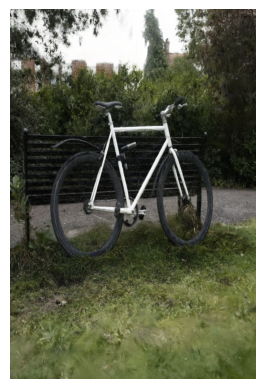

In [ ]:
# view the image with matplotlib
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# import math



# # ... (Load scales and opacities) ...
# scales = torch.clamp(scales, min=0.005) # Spoke fix

# # 1. Convert standard 2D opacity to a peak density value
# # Make sure this is squeezed to a flat 1D tensor: (N,)
# peak_2d_density = -torch.log(1.0 - opacities.clamp(max=0.999)).squeeze()

# # 2. Approximate the physical thickness of the Gaussian in 3D space.
# # Add .squeeze() to the end to flatten it from (N, 1) down to (N,)
# average_thickness = (scales.mean(dim=-1) * math.sqrt(2 * math.pi)).squeeze()

# # 3. Calculate True 3D Volumetric Density!
# # Now it is (N,) / (N,) which does perfect 1-to-1 math with zero memory explosion!
# true_volumetric_density = peak_2d_density / average_thickness


# # Overwrite the opacities tensor so the GPU receives the 3D density instead
# opacities_dsyg = true_volumetric_density


# # Make absolutely sure it's flat before sending to the device
# opacities_dsyg = opacities_dsyg.squeeze().to(rdv.device())

# opacities_dsyg = opacities_dsyg[mask]
# # Copy to Vulkan memory
# opacities_vk_dsyg = rdv.tensor_copy(opacities_dsyg)


In [ ]:
# 4. BUILD THE ACCELERATION DATA STRUCTURE
dsyg_map = rdv.DSYG(
    positions_vk, 
    colors_vk, 
    inv_covs=inv_covs_vk, 
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,   
    covs=covs_vk       
)
dsyg_map.build_ads()

In [ ]:
# 5. BUILD GS3D_Ratio (deterministic ratio-tracking variant) and GS3D_Sampled
#    (properly-sampled variant) -- same positions_vk/colors_vk/etc. as
#    gs_map/dsyg_map above, just a different per-ray blending shader
#    (decomposition_tracking_GS_ratio.h / decomposition_tracking_GS_sampled.h).
ratio_map = rdv.GS3D_Ratio(
    positions_vk,
    colors_vk,
    inv_covs=inv_covs_vk,
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,
    covs=covs_vk
)
ratio_map.build_ads()

sampled_map = rdv.GS3D_Sampled(
    positions_vk,
    colors_vk,
    inv_covs=inv_covs_vk,
    opacities=opacities_vk,
    scales=scales_vk,
    f_rest=f_rest_vk,
    covs=covs_vk
)
sampled_map.build_ads()

print("Ready to render GS3D_Ratio and GS3D_Sampled too!")

In [ ]:
# capture the field and get the first image (GS3D_Ratio)

capture_image = sensor.view(ratio_map, samples=1)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"GS3D_Ratio rendered in {time.perf_counter() - t} seconds")

In [ ]:
# view the image with matplotlib (GS3D_Ratio)
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.title('GS3D_Ratio')
plt.show()

In [ ]:
# capture the field and get the first image (GS3D_Sampled)

capture_image = sensor.view(sampled_map, samples=1)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"GS3D_Sampled rendered in {time.perf_counter() - t} seconds")

In [ ]:
# view the image with matplotlib (GS3D_Sampled)
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.title('GS3D_Sampled')
plt.show()

In [ ]:
# capture the field and get the first image

capture_image = sensor.view(dsyg_map, samples=1)
image = capture_image.capture()[0]

import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"Rendered in {time.perf_counter() - t} seconds")

Rendered in 60.32965675300056 seconds


In [ ]:
# # ACES formula (Hollywood standard color science)
# def aces_tonemap(x):
#     a = 2.51
#     b = 0.03
#     c = 2.43
#     d = 0.59
#     e = 0.14
#     # This formula gently curves ultra-bright light down to 1.0 instead of chopping it.
#     return torch.clamp((x * (a * x + b)) / (x * (c * x + d) + e), 0.0, 1.0)

# # 1. Apply ACES to fix the lighting
# image_tensor_aces = aces_tonemap(image)

# # 2. Apply standard Gamma for the monitor
# image_tensor_gamma = torch.pow(image_tensor_aces + 1e-5, 1.0 / 2.2)

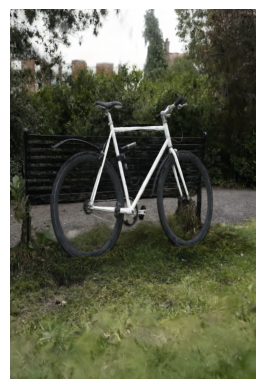

In [ ]:
# view the image with matplotlib
import matplotlib.pyplot as plt
plt.imshow(image.detach().cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.show()

## Comparing against the official 3D Gaussian Splatting results bundle

The `Gaussians/bicycle/` folder you added (`results.json`, `per_view.json`,
`test/<method>/{gt,renders}/`) is the official comparison bundle released
alongside the 3D Gaussian Splatting paper for this exact scene: real
ground-truth photos (already resized to whatever resolution `render.py`
used), the paper's own renders at 7k and 30k training iterations
(`ours_7000` / `ours_30000`), and three baselines they compared against
(`ingp` = Instant-NGP, `ingp-big` = Instant-NGP at higher capacity,
`mipnerf360` = the Mip-NeRF360 NeRF baseline this whole dataset is named
after). `results.json` holds the scene-level PSNR/SSIM/LPIPS the paper
reports for each; `per_view.json` breaks it down per held-out image.

Checked directly (pixel comparison) before writing any of this: every
method's `gt/` folder holds the exact same 25 photos, just under different
filename schemes -- `ours_*`/`ingp*` keep the original `_DSC####.png` /
`DSC####.png` names, `mipnerf360` renames them to `000.png`..`024.png` --
but sorting each folder's file list independently lines them up
index-for-index with the same underlying camera. That's also exactly 25
images, matching the "every 8th image" held-out split already used
elsewhere in this notebook, so this bundle's test set is the same one
`--eval` training produces. The next cell re-verifies this alignment on
YOUR copy of the bundle rather than assuming it holds here too.

This section renders all four of your own methods -- `gs_map` (GS3D),
`dsyg_map` (DSYG), `ratio_map` (GS3D_Ratio), and `sampled_map`
(GS3D_Sampled) -- at those same 25 held-out camera poses, measures
PSNR/SSIM/LPIPS against the SAME ground-truth photos the paper's numbers
were computed against, and puts everything in one table -- plus a
side-by-side image grid so you can actually look at the differences, not
just read numbers.

**This depends on the `make_sensor` fix earlier in the notebook** (the
cell right before the real-camera `sensor` cell) -- without it, your
renders come out with width and height swapped relative to every image in
this bundle.


In [ ]:
import json
import os

test_root = "/content/drive/MyDrive/Gaussians/bicycle/test"

with open("/content/drive/MyDrive/Gaussians/bicycle/results.json") as f:
    official_results = json.load(f)
with open("/content/drive/MyDrive/Gaussians/bicycle/per_view.json") as f:
    official_per_view = json.load(f)

baseline_methods = sorted(
    m for m in os.listdir(test_root)
    if os.path.isdir(os.path.join(test_root, m))
)
print("Baseline methods on disk:", baseline_methods)
print("Baseline methods in results.json:", list(official_results.keys()))


In [ ]:
from PIL import Image
import numpy as np

CANONICAL_METHOD = "ours_30000"  # any method works as the source of truth for gt filenames -- they're pixel-identical


def official_test_views(test_root, methods, canonical=CANONICAL_METHOD):
    """
    One entry per held-out view, sorted consistently across every method's
    folder. Filenames differ by method (mipnerf360 uses 000.png..024.png,
    ours_*/ingp* keep the original photo names) but sorting each folder's
    file list independently lines the SAME camera up at the SAME index --
    verified below on your actual copy of the bundle, not just assumed.
    """
    gt_files = {m: sorted(os.listdir(os.path.join(test_root, m, 'gt'))) for m in methods}
    render_files = {m: sorted(os.listdir(os.path.join(test_root, m, 'renders'))) for m in methods}

    n = len(gt_files[canonical])
    for m in methods:
        assert len(gt_files[m]) == n, f"{m} has {len(gt_files[m])} gt images, expected {n} (like {canonical})"

    views = []
    for i in range(n):
        views.append(dict(
            index=i,
            gt_filename=gt_files[canonical][i],
            gt_path=os.path.join(test_root, canonical, 'gt', gt_files[canonical][i]),
            render_paths={m: os.path.join(test_root, m, 'renders', render_files[m][i]) for m in methods},
            gt_paths={m: os.path.join(test_root, m, 'gt', gt_files[m][i]) for m in methods},
        ))
    return views


test_views = official_test_views(test_root, baseline_methods)
print(f"{len(test_views)} held-out views")

# Sanity check: confirm the sorted-index alignment actually holds on YOUR
# copy of this bundle, rather than trusting it blindly.
check_idx = 0
ref = np.asarray(Image.open(test_views[check_idx]['gt_paths'][CANONICAL_METHOD]).convert('RGB'), dtype=np.float32)
print(f"Checking index {check_idx} across methods (mean abs pixel diff vs {CANONICAL_METHOD}'s gt):")
for m in baseline_methods:
    other_img = Image.open(test_views[check_idx]['gt_paths'][m]).convert('RGB')
    if other_img.size != (ref.shape[1], ref.shape[0]):
        other_img = other_img.resize((ref.shape[1], ref.shape[0]))
    other = np.asarray(other_img, dtype=np.float32)
    diff = np.abs(other - ref).mean()
    flag = "OK" if diff < 5.0 else "MISMATCH -- index alignment may be wrong for this method"
    print(f"  {m}: {diff:.3f}  [{flag}]")


In [ ]:
!pip install scikit-image lpips pandas -q

import math
from skimage.metrics import structural_similarity as _skimage_ssim


def psnr(img, ref, max_val=1.0):
    mse = float(((img - ref) ** 2).mean())
    if mse == 0:
        return float('inf')
    return 10.0 * math.log10((max_val ** 2) / mse)


def ssim(img, ref):
    return float(_skimage_ssim(img, ref, channel_axis=2, data_range=1.0))


_lpips_model = None
def lpips_score(img, ref, device=None):
    """img, ref: (H,W,3) numpy arrays in [0,1]."""
    global _lpips_model
    if _lpips_model is None:
        import lpips as _lpips_pkg
        _lpips_model = _lpips_pkg.LPIPS(net='alex')
        if device is not None:
            _lpips_model = _lpips_model.to(device)
    t_img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
    t_ref = torch.from_numpy(ref).permute(2, 0, 1).unsqueeze(0).float()
    if device is not None:
        t_img, t_ref = t_img.to(device), t_ref.to(device)
    with torch.no_grad():
        d = _lpips_model(t_img, t_ref, normalize=True)  # normalize=True: inputs are [0,1], not [-1,1]
    return float(d.item())


def _img_key(cam):
    for k in ('img_name', 'image_name', 'file_path', 'filename', 'image_path'):
        if k in cam:
            return cam[k]
    return str(cam.get('id', id(cam)))


def find_camera_for_filename(cameras_data, filename):
    """Match a bundle image filename (e.g. '_DSC8679.png') back to its
    camera pose in cameras.json, ignoring the leading underscore some
    folders add and the file extension."""
    target = os.path.splitext(filename)[0].lstrip('_')
    for c in cameras_data:
        key = os.path.splitext(str(_img_key(c)))[0].lstrip('_')
        if key == target:
            return c
    return None


In [ ]:
import time

own_methods = {'GS3D': gs_map, 'DSYG': dsyg_map}
if 'ratio_map' in globals():
    own_methods['GS3D_Ratio'] = ratio_map
if 'sampled_map' in globals():
    own_methods['GS3D_Sampled'] = sampled_map

SCORING_SAMPLES = 16  # samples per pixel for both the quality metrics AND the render-time/fps
                       # measurement below -- lower than the 32 used before, closer to what
                       # you'd actually run interactively, and faster to iterate on.

own_per_view = {name: [] for name in own_methods}
skipped = []

# Warm up each method once before timing. The FIRST dispatch of a given
# map/shape/generics combination compiles its compute pipeline (rdv caches
# it after that -- see _DispatcherEngine.__EVAL_PIPELINES__), so timing the
# first view of each method without a warm-up would mix one-time
# compilation cost into what's supposed to be a per-frame render time.
warmup_view = test_views[0]
warmup_cam = find_camera_for_filename(cameras_data, warmup_view['gt_filename'])
if warmup_cam is not None:
    wW, wH = Image.open(warmup_view['gt_path']).size
    w_pos = np.array(warmup_cam['position']); w_rot = np.array(warmup_cam['rotation'])
    w_forward = w_rot[:, 2]; w_up = -w_rot[:, 1]; w_target = w_pos + w_forward
    w_pose_list = [w_pos[0], w_pos[1], w_pos[2], w_target[0], w_target[1], w_target[2], w_up[0], w_up[1], w_up[2]]
    warmup_camera_poses = rdv.tensor_copy(torch.tensor(w_pose_list, dtype=torch.float32).reshape(1, 9))
    warmup_sensor = make_sensor(wW, wH, warmup_camera_poses, cam=warmup_cam)
    for name, model in own_methods.items():
        warmup_sensor.view(model, samples=SCORING_SAMPLES).capture()[0]
    print("Warm-up render done for all methods (pipelines compiled).")

for view in test_views:
    matched_cam = find_camera_for_filename(cameras_data, view['gt_filename'])
    if matched_cam is None:
        skipped.append(view['gt_filename'])
        continue

    ref = np.asarray(Image.open(view['gt_path']).convert('RGB'), dtype=np.float32) / 255.0
    W, H = Image.open(view['gt_path']).size  # match the OFFICIAL bundle's resolution, not cameras.json's --
                                              # they may not agree if your own training run used a different
                                              # downsample factor than this released bundle did.

    v_pos = np.array(matched_cam['position'])
    v_rot = np.array(matched_cam['rotation'])
    v_forward = v_rot[:, 2]
    v_up = -v_rot[:, 1]
    v_target = v_pos + v_forward
    v_pose_list = [v_pos[0], v_pos[1], v_pos[2], v_target[0], v_target[1], v_target[2], v_up[0], v_up[1], v_up[2]]
    view_camera_poses = rdv.tensor_copy(torch.tensor(v_pose_list, dtype=torch.float32).reshape(1, 9))
    view_sensor = make_sensor(W, H, view_camera_poses, cam=matched_cam)

    for name, model in own_methods.items():
        view_task = view_sensor.view(model, samples=SCORING_SAMPLES)
        t0 = time.perf_counter()
        rendered = view_task.capture()[0]
        render_seconds = time.perf_counter() - t0  # .capture() blocks until the GPU work is
                                                    # done -- same assumption your own earlier
                                                    # "Rendered in X seconds" cells already make.

        arr = np.clip(rendered.detach().cpu().numpy(), 0.0, 1.0)
        arr = np.flipud(arr)  # same row0=bottom convention already used elsewhere in this notebook

        if arr.shape != ref.shape:
            print(f"WARNING: shape mismatch for {view['gt_filename']} ({name}): "
                  f"rendered {arr.shape} vs photo {ref.shape} -- skipping this view/method. "
                  f"If this keeps happening, double check the make_sensor cell fix took effect.")
            continue

        own_per_view[name].append(dict(
            filename=view['gt_filename'],
            psnr=psnr(arr, ref), ssim=ssim(arr, ref), lpips=lpips_score(arr, ref, device=rdv.device()),
            render_seconds=render_seconds,
            fps=(1.0 / render_seconds) if render_seconds > 0 else float('inf'),
        ))
    print(f"scored {view['gt_filename']}  ({view['index'] + 1}/{len(test_views)})")

if skipped:
    print(f"WARNING: {len(skipped)} bundle images had no matching camera in cameras.json "
          f"(check the img_name/image_name field spelling): {skipped}")


In [ ]:
import pandas as pd

# This bundle's own results.json/per_view.json use the key 'ours_70000' for
# what's on disk as the 'ours_7000' folder -- a naming mismatch in the
# released bundle itself, not something introduced here.
_KNOWN_KEY_ALIASES = {'ours_7000': 'ours_70000'}


def _official_key(name):
    if name in official_results:
        return name
    alias = _KNOWN_KEY_ALIASES.get(name)
    if alias in official_results:
        return alias
    return None


rows = []
for name in baseline_methods:
    key = _official_key(name)
    if key is None:
        print(f"WARNING: no results.json entry for '{name}' -- skipping its row in the table "
              f"(its images are still available above for the visual grid).")
        continue
    m = official_results[key]
    # the released bundle doesn't publish per-view render time, so these stay NaN for paper rows
    rows.append(dict(source=f"paper: {name}", psnr=m['PSNR'], ssim=m['SSIM'], lpips=m['LPIPS'],
                      render_seconds=None, fps=None))

for name, per_view in own_per_view.items():
    if not per_view:
        continue
    df_pv = pd.DataFrame(per_view)
    rows.append(dict(source=f"ours: {name}", psnr=df_pv['psnr'].mean(),
                      ssim=df_pv['ssim'].mean(), lpips=df_pv['lpips'].mean(),
                      render_seconds=df_pv['render_seconds'].mean(), fps=df_pv['fps'].mean()))

comparison_table = pd.DataFrame(rows).set_index('source')
print(comparison_table)
# higher psnr/ssim/fps is better, lower lpips/render_seconds is better.
# render_seconds/fps are only measured for "ours: *" rows (see SCORING_SAMPLES above) --
# the paper doesn't publish comparable per-view timing for the baselines.

comparison_table.to_csv("/content/drive/MyDrive/Gaussians/bicycle/bicycle_comparison_table.csv")


In [ ]:
import matplotlib.pyplot as plt

own_speed_rows = comparison_table[comparison_table.index.str.startswith('ours: ')].dropna(subset=['fps'])

if own_speed_rows.empty:
    print("No timing data to plot -- own_per_view looks empty, check the scoring cell above ran.")
else:
    labels = [s.replace('ours: ', '') for s in own_speed_rows.index]
    colors = plt.get_cmap('tab10').colors

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(labels, own_speed_rows['render_seconds'], color=colors[:len(labels)])
    axes[0].set_ylabel('seconds per frame (lower better)')
    axes[0].set_title(f'Render time @ {SCORING_SAMPLES} spp')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(labels, own_speed_rows['fps'], color=colors[:len(labels)])
    axes[1].set_ylabel('FPS (higher better)')
    axes[1].set_title('Render speed')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Gaussians/bicycle/bicycle_speed_chart.png", dpi=150)
    plt.show()

    print()
    print("Remember: GS3D and GS3D_Sampled are stochastic -- their time at "
          f"{SCORING_SAMPLES} spp buys less converged (noisier) quality than DSYG/GS3D_Ratio's "
          "single deterministic pass at the same spp value. Faster isn't directly comparable to "
          "faster unless you also check the psnr/ssim/lpips columns in the table above together with it.")


In [ ]:
import matplotlib.pyplot as plt

view_index = 0  # change this (0..24) to look at a different held-out view

grid_view = test_views[view_index]
panels = [('ground truth', grid_view['gt_path'])]
for m in baseline_methods:
    panels.append((m, grid_view['render_paths'][m]))

grid_cam = find_camera_for_filename(cameras_data, grid_view['gt_filename'])
if grid_cam is None:
    print(f"No matching camera for {grid_view['gt_filename']} -- showing baselines only, no 'ours: *' panels.")
else:
    gW, gH = Image.open(grid_view['gt_path']).size
    g_pos = np.array(grid_cam['position'])
    g_rot = np.array(grid_cam['rotation'])
    g_forward = g_rot[:, 2]
    g_up = -g_rot[:, 1]
    g_target = g_pos + g_forward
    g_pose_list = [g_pos[0], g_pos[1], g_pos[2], g_target[0], g_target[1], g_target[2], g_up[0], g_up[1], g_up[2]]
    grid_camera_poses = rdv.tensor_copy(torch.tensor(g_pose_list, dtype=torch.float32).reshape(1, 9))
    grid_sensor = make_sensor(gW, gH, grid_camera_poses, cam=grid_cam)
    for name, model in own_methods.items():
        rendered = grid_sensor.view(model, samples=SCORING_SAMPLES).capture()[0]
        arr = np.flipud(np.clip(rendered.detach().cpu().numpy(), 0.0, 1.0))
        panels.append((f"ours: {name}", arr))

n_panels = len(panels)
cols = 3
grid_rows = (n_panels + cols - 1) // cols
fig, axes = plt.subplots(grid_rows, cols, figsize=(5 * cols, 4 * grid_rows))
axes = np.atleast_2d(axes).reshape(-1)
for ax, (label, data) in zip(axes, panels):
    img = data if isinstance(data, np.ndarray) else np.asarray(Image.open(data).convert('RGB'), dtype=np.float32) / 255.0
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis('off')
for ax in axes[len(panels):]:
    ax.axis('off')
plt.suptitle(f"Held-out view: {grid_view['gt_filename']}")
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/Gaussians/bicycle/comparison_grid_view{view_index}.png", dpi=150)
plt.show()
